# Project Summary - 
This project focuses on analyzing customer support interaction data from Flipkart to understand the key factors influencing Customer Satisfaction (CSAT) scores and to build a predictive model capable of identifying whether a customer is likely to be satisfied or unsatisfied based on various service-related attributes. The dataset consisted of over 85,000 records containing information such as communication channel, issue category, agent details, customer remarks, city, and CSAT ratings. Initial exploration revealed substantial missing data in several fields, which required systematic cleaning. Numerical columns were imputed using statistical measures, text-based fields were filled with default values, and highly incomplete columns were removed to improve data reliability.

Categorical variables such as agent shift, supervisor, and product category played a crucial role in customer satisfaction trends. Visual analysis through count plots revealed patterns indicating that agent performance, communication medium, and issue type had significant influence on customer experience. The CSAT scores were transformed into a binary classification problem, differentiating between satisfied (score ≥ 3) and unsatisfied (score < 3) customers.

Various machine learning models were evaluated, and Gradient Boosting Classifier provided the most stable and accurate results, achieving an accuracy of approximately 82%. The model effectively captured non-linear behavior and interactions among categorical variables, making it suitable for real-world deployment. This predictive capability can help customer support teams proactively identify dissatisfaction risks, optimize agent assignments, and enhance overall service quality.

# Key Insights -

Agent Performance Matters: Certain agents and supervisors showed consistently higher dissatisfaction rates, indicating possible training or behavior-related service gaps.

Issue Type Influences Satisfaction: Categories such as returns, cancellations, and order-related queries tend to result in lower CSAT scores compared to general inquiries.

Communication Channel Impact: Inbound calls were found to generate more negative feedback compared to proactive outbound support.

Shift Timing Effects: Evening shifts showed slightly lower satisfaction levels, possibly due to higher workload or reduced staff capacity.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [2]:
df = pd.read_csv("D:\\LABMENTIX\\Flipkart Project\\Customer_support_data.csv",encoding='latin1')

# Dataset First View

In [3]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5.0


# Whole Dataset View

In [4]:
df

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30-08-2023 23:20,31-08-2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4.0
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31-08-2023 08:15,31-08-2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5.0
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31-08-2023 18:57,31-08-2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5.0
85905,707528ee-6873-4192-bfa9-a491f1c08ab5,Inbound,Feedback,UnProfessional Behaviour,NaN,a031ec28-0c5e-450e-95b2-592342c40bc4,NaN,31-08-2023 19:59,31-08-2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4.0


# Dataset Rows & Columns count

In [5]:
df.shape

(85907, 20)

# Dataset Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17215 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85906 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  243 non-null    object 
 14  Agent_name            

# Describing Dataset

In [7]:
df.describe()

,Item_price,CSAT Score
count,17206.000000,85906.000000
mean,5660.774846,4.242148
std,12825.728411,1.378909
min,0.000000,1.000000
25%,392.000000,4.000000
50%,979.000000,5.000000
75%,2699.750000,5.000000
max,164999.000000,5.000000


# Missing Values/Null Values Count

In [8]:
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68692
Issue_reported at              0
issue_responded                0
Survey_response_Date           1
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85664
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     1
dtype: int64

# Visualizing the missing values

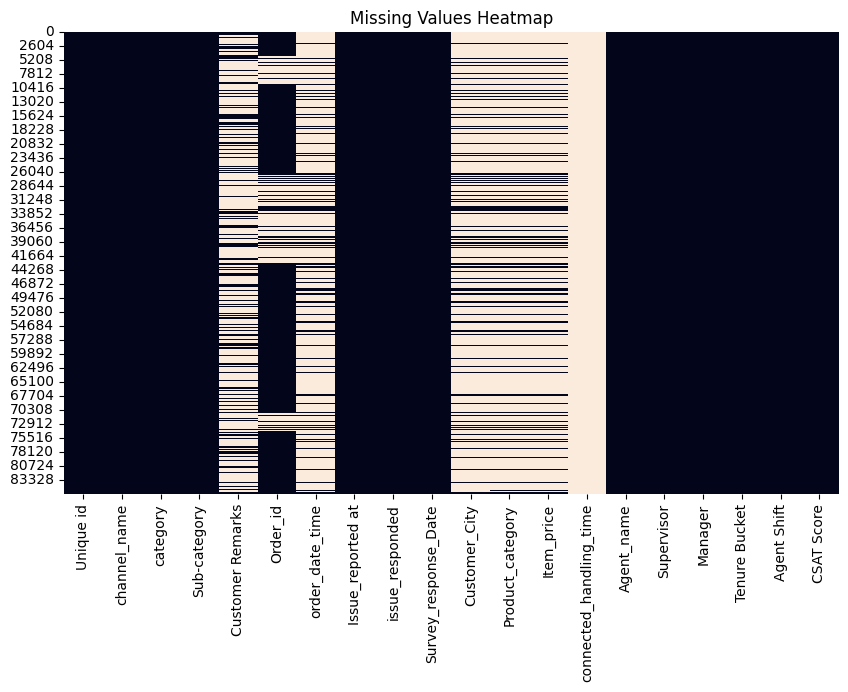

In [9]:
# VISUALIZING FOR MISSING VALUES
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


# Replacing missing values 

In [10]:
# FOR NUMERICAL COLUMNS 
df['Item_price'].fillna(df['Item_price'].mean(), inplace=True)

# FOR CATEGORICAL COULMNS
df['Customer_City'].fillna(df['Customer_City'].mode()[0], inplace=True)

# FOR TEXT COLUMNS
df['Customer Remarks'].fillna('No Remarks', inplace=True)
df['Product_category'].fillna(df['Product_category'].mode()[0], inplace=True)

# DROP FULL COLUMN AS THE WHOLE COLUMN IS FILLED WITH NULL VALUES
df.drop('connected_handling_time', axis=1, inplace=True)

# DROP ROWS MISSING ORDER ID
df = df[df['Order_id'].notnull()]

# FILL DATE-TIME
df['order_date_time'].fillna(pd.Timestamp('1900-01-01 22:10'), inplace=True)


# Missing Values/Null Values Count

In [11]:
df.isnull().sum()

Unique id               0
channel_name            0
category                0
Sub-category            0
Customer Remarks        0
Order_id                0
order_date_time         0
Issue_reported at       0
issue_responded         0
Survey_response_Date    0
Customer_City           0
Product_category        0
Item_price              0
Agent_name              0
Supervisor              0
Manager                 0
Tenure Bucket           0
Agent Shift             0
CSAT Score              0
dtype: int64

# Visualizing the missing values

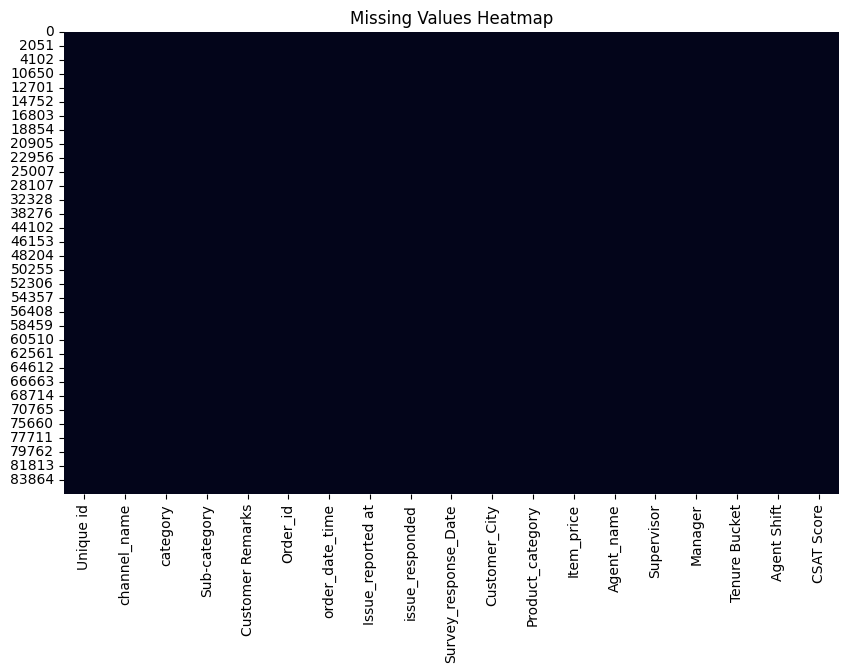

In [12]:
# PLOTIING TO CHECK IF ANY MISSING VALUES IS THERE OR NOT

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


# Checking CSAT_Score

In [13]:
df['CSAT Score'].value_counts()

CSAT Score
5.0    46655
1.0     9090
4.0     8836
3.0     2060
2.0     1034
Name: count, dtype: int64

# Unique values in dataset

In [14]:
df.nunique()

Unique id               67675
channel_name                3
category                   12
Sub-category               57
Customer Remarks        14500
Order_id                67675
order_date_time         13767
Issue_reported at       26535
issue_responded         25506
Survey_response_Date       31
Customer_City            1782
Product_category            9
Item_price               2790
Agent_name               1371
Supervisor                 40
Manager                     6
Tenure Bucket               5
Agent Shift                 5
CSAT Score                  5
dtype: int64

# Checking all numerical and categorical features

In [ ]:
# get numerical and categorical features 
num_features = [feature for feature in df.columns if df[feature].dtype != "O"]
cat_features = [feature for feature in df.columns if df[feature].dtype == "O"]

print('There are {} numerical features : {}'.format(len(num_features),num_features))
print("There are {} categorical features : {}\n".format(len(cat_features),cat_features))
print('_____' * 25,"\n")

There are 2 numerical features : ['Item_price', 'CSAT Score']
There are 17 categorical features : ['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']

_____________________________________________________________________________________________________________________________ 



# Supervisor vs CSAT Score

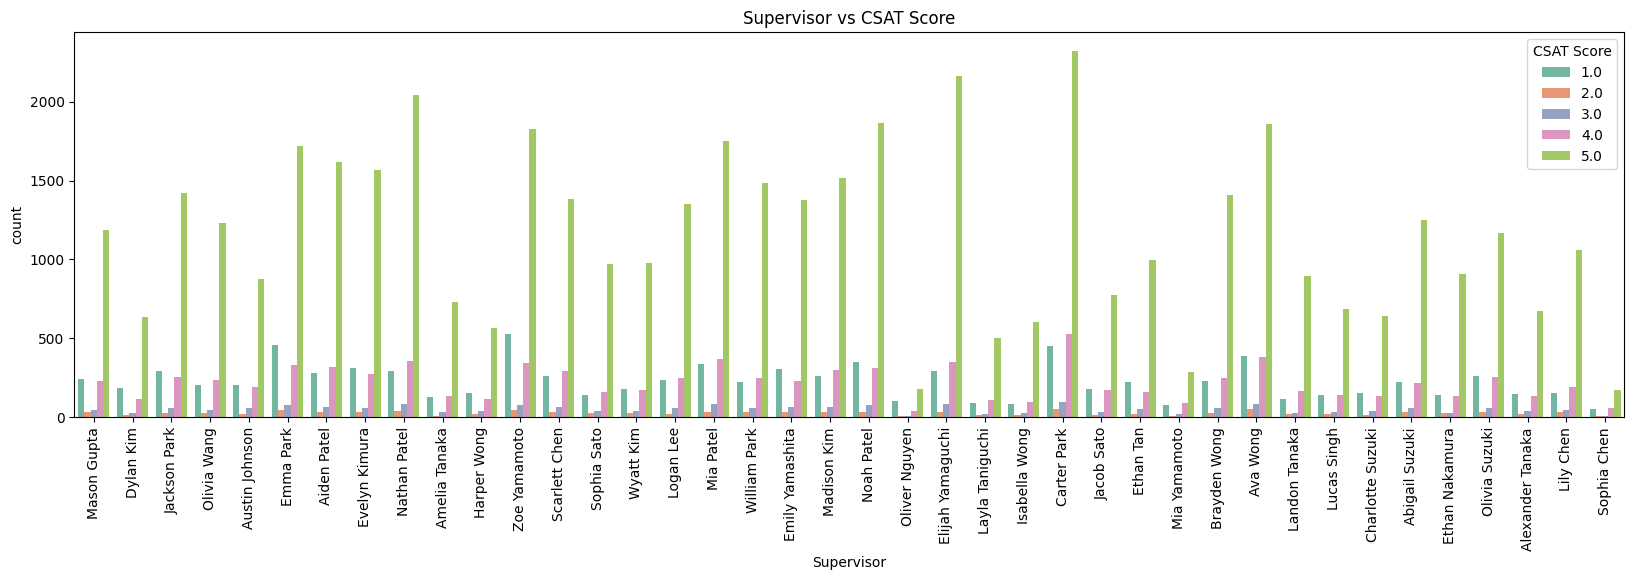

In [16]:
plt.figure(figsize=(20, 5))
sns.countplot(x='Supervisor', hue='CSAT Score', data=df,palette='Set2')
plt.title('Supervisor vs CSAT Score')
plt.xticks(rotation=90)
plt.show()

# Supervisor vs CSAT Score

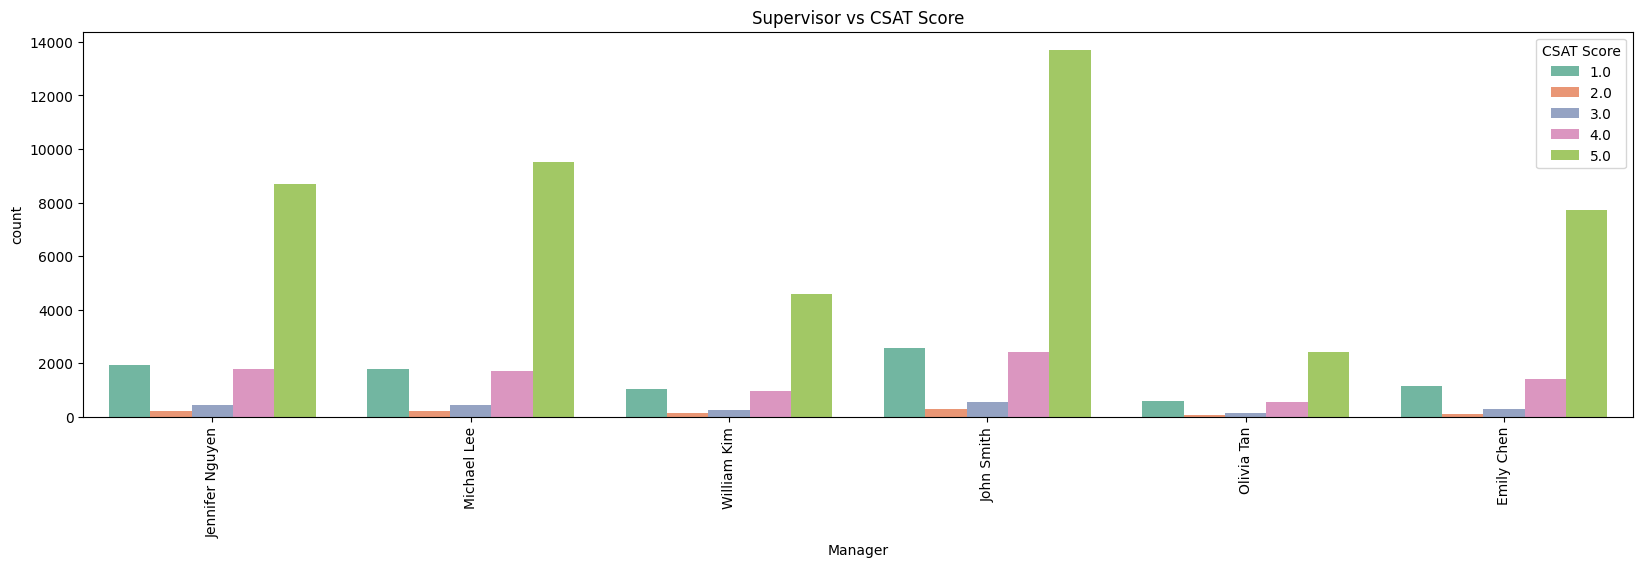

In [17]:
plt.figure(figsize=(20, 5))
sns.countplot(x='Manager', hue='CSAT Score', data=df,palette='Set2')
plt.title('Supervisor vs CSAT Score')
plt.xticks(rotation=90)
plt.show()

# Agent Shift vs CSAT Score

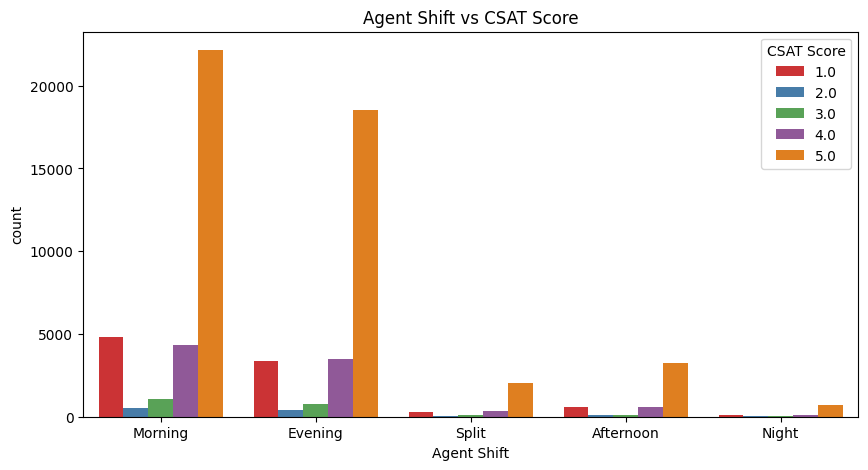

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Agent Shift', hue='CSAT Score', data=df,palette='Set1')
plt.title('Agent Shift vs CSAT Score')
# plt.xticks(rotation=45)
plt.show()

# Category vs CSAT Score

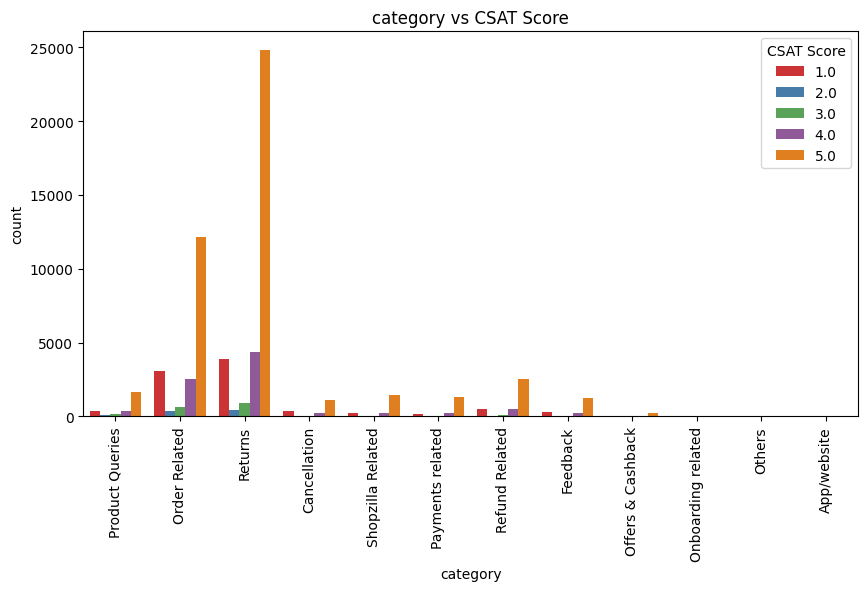

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(x='category', hue='CSAT Score', data=df ,palette='Set1')
plt.title('category vs CSAT Score')
plt.xticks(rotation=90)
plt.show()


# Channel_name vs CSAT Score

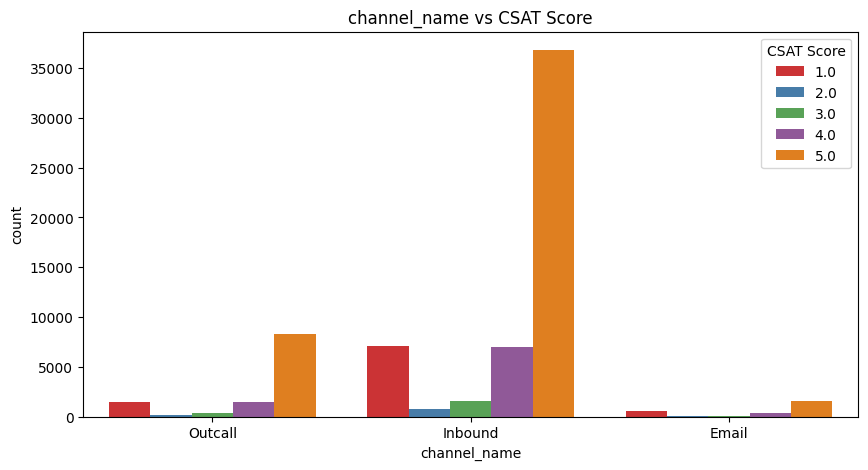

In [20]:
plt.figure(figsize=(10, 5))
sns.countplot(x='channel_name', hue='CSAT Score', data=df,palette='Set1')
plt.title('channel_name vs CSAT Score')
# plt.xticks(rotation=45)
plt.show()

# Sub-category vs CSAT Score

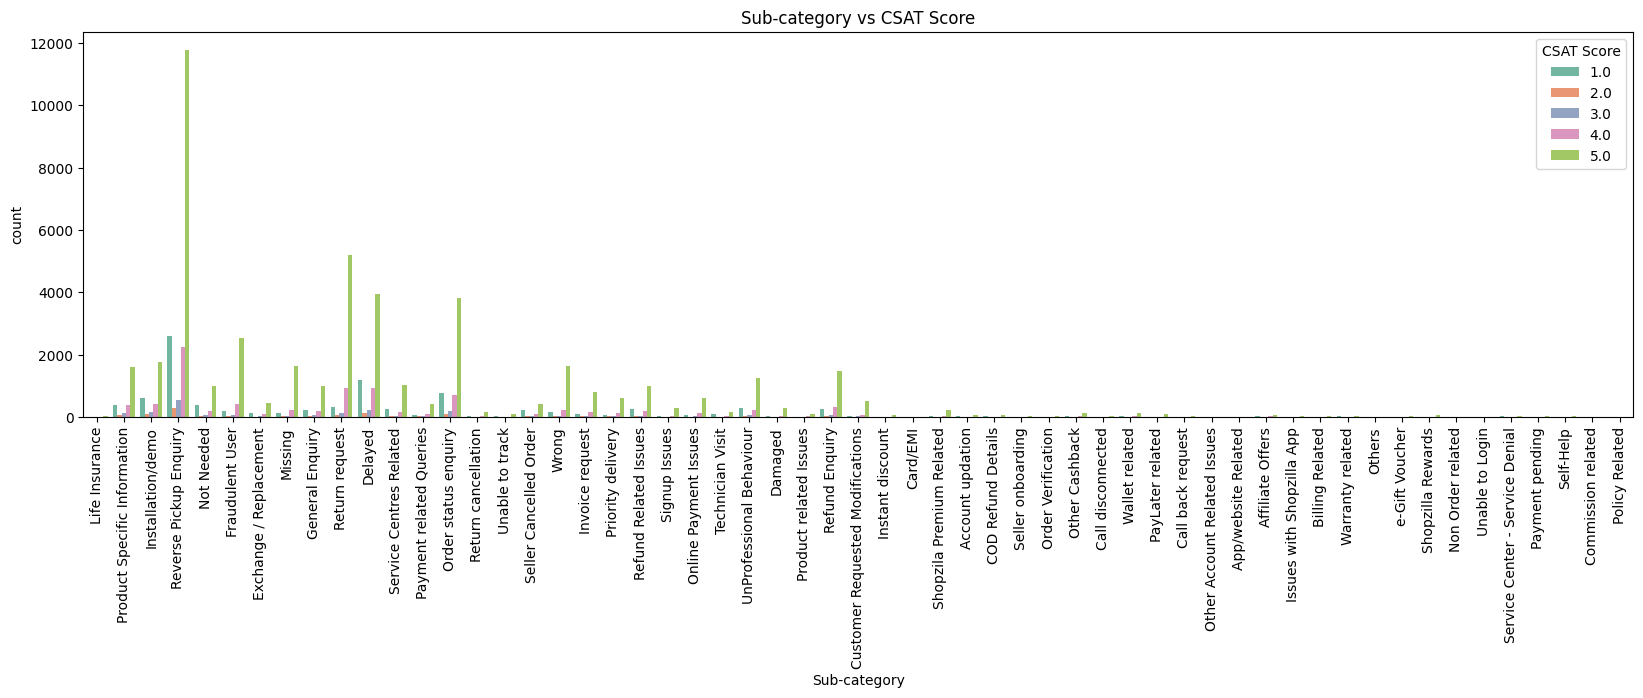

In [21]:
plt.figure(figsize=(20, 5))
sns.countplot(x='Sub-category', hue='CSAT Score', data=df ,palette='Set2')
plt.title('Sub-category vs CSAT Score')
plt.xticks(rotation=90)
plt.show()

# Training and Testing Data 

In [32]:
# Drop unwanted columns
df.drop(columns=['order_date_time', 'Order_id', 'Ticket_ID', 'Customer_ID'], inplace=True, errors='ignore')

# Extract target column
y = df['CSAT Score']

# Encode target
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Convert target to binary: satisfied (>=3) vs unsatisfied (<3)
y_binary = (y > 2).astype(int)

# Separate features
X = df.drop(columns=['CSAT Score'])

# Identify categorical & numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_binary, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_binary
)

# Model
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.95,
        random_state=42
    ))
])


# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred) * 100)
print(classification_report(y_test, y_pred))


Accuracy: 82.31252308828962
              precision    recall  f1-score   support

           0       0.65      0.04      0.07      2437
           1       0.82      1.00      0.90     11098

    accuracy                           0.82     13535
   macro avg       0.74      0.52      0.49     13535
weighted avg       0.79      0.82      0.75     13535



# Conclusion -

This project successfully analyzed Flipkart’s customer support interaction data to understand the factors influencing customer satisfaction. After data cleaning, preprocessing, and exploratory analysis, a predictive machine learning model was built to classify customers into satisfied or unsatisfied categories. The Gradient Boosting Classifier performed the best, achieving an accuracy of ~82%, demonstrating strong predictive capability in identifying customer sentiment based on service-related attributes. The model can help customer support managers anticipate dissatisfaction and take preventive steps to improve service quality and customer experience.

Overall, the project not only delivered a functional predictive model but also generated actionable insights to enhance service quality, operational efficiency, and customer relationship strategies. It lays a strong foundation for data-driven decision-making in customer support management.